## Import & Config


In [58]:
import json
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

# PATH
DATASET_PATH = "/kaggle/input/datasets/sonlest/bom-dataset-v1/BOM-Dataset"
JSON_PATH = "/kaggle/input/datasets/sonlest/bom-dataset-v1/cleaned_instances.json"

OUTPUT_PATH = "/kaggle/working/balanced_dataset"
OUTPUT_IMG_PATH = os.path.join(OUTPUT_PATH, "images")
OUTPUT_JSON_PATH = os.path.join(OUTPUT_PATH, "instances_balanced.json")

os.makedirs(OUTPUT_IMG_PATH, exist_ok=True)

## Load & Save JSON

In [59]:
def load_data(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

In [60]:
def get_class_distribution(data):
    class_counts = defaultdict(int)
    class_map = {c['id']: c['name'] for c in data['categories']}

    for ann in data['annotations']:
        class_name = class_map[ann['category_id']]
        class_counts[class_name] += 1

    return class_counts, class_map

In [61]:
def plot_distribution(class_counts, title):
    names = list(class_counts.keys())
    values = list(class_counts.values())

    plt.figure()
    plt.bar(names, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

In [62]:
def augment_image(image, bboxes):
    w, h = image.size

    # flip ngang
    image = image.transpose(Image.FLIP_LEFT_RIGHT)

    new_bboxes = []
    for bbox in bboxes:
        x, y, bw, bh = bbox
        new_x = w - x - bw
        new_bboxes.append([new_x, y, bw, bh])

    return image, new_bboxes

In [63]:
def group_annotations(data):
    img_to_anns = defaultdict(list)
    for ann in data['annotations']:
        img_to_anns[ann['image_id']].append(ann)
    return img_to_anns

In [64]:
def balance_dataset(data):

    class_counts, class_map = get_class_distribution(data)
    img_to_anns = group_annotations(data)

    # target = max class
    target = max(class_counts.values())

    print("🎯 Target per class:", target)

    new_images = list(data['images'])
    new_annotations = list(data['annotations'])

    next_img_id = max(img['id'] for img in new_images) + 1
    next_ann_id = max(ann['id'] for ann in new_annotations) + 1

    # gom annotations theo class
    class_to_anns = defaultdict(list)
    for ann in data['annotations']:
        class_name = class_map[ann['category_id']]
        class_to_anns[class_name].append(ann)

    for class_name, anns in class_to_anns.items():
        current_count = len(anns)

        if current_count >= target:
            continue  # ❌ KHÔNG augment class lớn

        needed = target - current_count
        print(f"🔄 Augment {class_name}: +{needed}")

        for _ in tqdm(range(needed)):
            ann = random.choice(anns)

            # lấy image
            img_info = next(img for img in data['images'] if img['id'] == ann['image_id'])
            img_path = os.path.join(DATASET_PATH, img_info['file_name'])

            image = Image.open(img_path).convert("RGB")

            # lấy tất cả bbox trong ảnh
            anns_in_img = img_to_anns[img_info['id']]
            bboxes = [a['bbox'] for a in anns_in_img]

            # augment
            aug_img, aug_bboxes = augment_image(image, bboxes)

            # save ảnh
            new_filename = f"aug_{next_img_id}.jpg"
            aug_img.save(os.path.join(OUTPUT_IMG_PATH, new_filename))

            new_images.append({
                "id": next_img_id,
                "file_name": new_filename,
                "width": image.width,
                "height": image.height
            })

            # add annotations
            for a, bbox in zip(anns_in_img, aug_bboxes):
                new_annotations.append({
                    "id": next_ann_id,
                    "image_id": next_img_id,
                    "category_id": a['category_id'],
                    "bbox": bbox,
                    "area": bbox[2] * bbox[3],
                    "iscrowd": 0
                })
                next_ann_id += 1

            next_img_id += 1

    data['images'] = new_images
    data['annotations'] = new_annotations

    return data

In [65]:
def save_dataset(data, output_json_path):
    with open(output_json_path, 'w') as f:
        json.dump(data, f)

In [66]:
def copy_original_images(data):
    for img in data['images']:
        src = os.path.join(DATASET_PATH, img['file_name'])
        dst = os.path.join(OUTPUT_IMG_PATH, img['file_name'])

        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy(src, dst)

🚀 Loading dataset...

📊 BEFORE BALANCING
defaultdict(<class 'int'>, {'PartDrawing': 105, 'Note': 33, 'Table': 63})


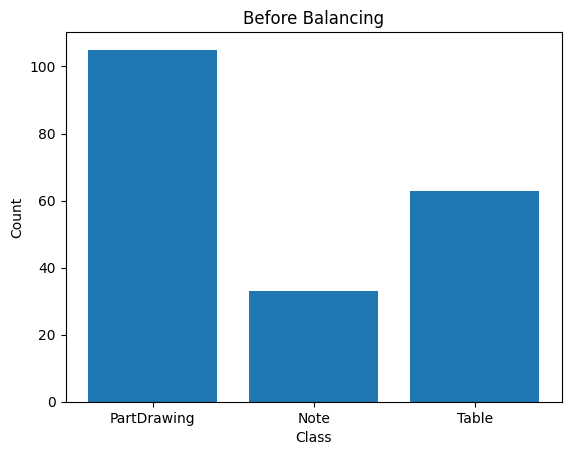


⚖️ Balancing dataset...
🎯 Target per class: 105
🔄 Augment Note: +72


100%|██████████| 72/72 [00:01<00:00, 51.98it/s]


🔄 Augment Table: +42


100%|██████████| 42/42 [00:00<00:00, 52.03it/s]



📊 AFTER BALANCING
defaultdict(<class 'int'>, {'PartDrawing': 286, 'Note': 207, 'Table': 227})


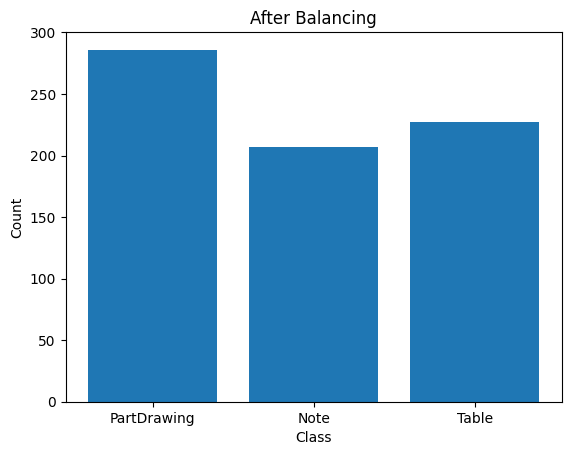


💾 Saving dataset...

📁 Copying images...

✅ DONE


In [67]:
def main():
    print("🚀 Loading dataset...")
    data = load_data(JSON_PATH)

    print("\n📊 BEFORE BALANCING")
    class_counts, _ = get_class_distribution(data)
    print(class_counts)
    plot_distribution(class_counts, "Before Balancing")

    print("\n⚖️ Balancing dataset...")
    balanced_data = balance_dataset(data)

    print("\n📊 AFTER BALANCING")
    new_counts, _ = get_class_distribution(balanced_data)
    print(new_counts)
    plot_distribution(new_counts, "After Balancing")

    print("\n💾 Saving dataset...")
    save_dataset(balanced_data, OUTPUT_JSON_PATH)

    print("\n📁 Copying images...")
    copy_original_images(balanced_data)

    print("\n✅ DONE")

main()